In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import math as m

In [2]:
import tqdm
import kagglehub, os

c:\Users\Miguel Almeida\envs\sw1pers_l_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
key = "energy_consumption"

FILE = "tetuan-city-power-consumption"

path = kagglehub.dataset_download(f"gmkeshav/{FILE}")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Downloaded files:", files)
df = pd.read_csv(os.path.join(path, files[0]))
df.info()

# store files locally
# df.to_parquet(f'{FILE}.parquet')

Path to dataset files: C:\Users\Miguel Almeida\.cache\kagglehub\datasets\gmkeshav\tetuan-city-power-consumption\versions\1
Downloaded files: ['Tetuan City power consumption.csv']
<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB


In [ ]:
# t_1, ..., t_S

# Set the period
period = 144    # S / L

L = 40

instances = period*L    # S = 144 * L

column = 'Zone 1 Power Consumption'

# Read from stored files
# df = pd.read_parquet(f'{FILE}.parquet')

dates_energy = df["DateTime"].values[0:instances]

energy_consumption = df[column].values[0:instances]

In [8]:
if key == "energy_consumption":
    ts = energy_consumption
    dates = dates_energy

In [9]:
#requires "pip install -e ." from root directory

import sw1pers_l
from sw1pers_l.core import SW1PerS, SW1PerS_L

Factor = 2

window_size = len(time_series)/35
window_stride = window_size/4
Finding best parameters...



100%|██████████| 137/137 [00:12<00:00, 11.11it/s]



Forming point clouds...



100%|██████████| 137/137 [00:01<00:00, 124.55it/s]



Forming persistence diagrams...



100%|██████████| 137/137 [00:04<00:00, 28.21it/s]


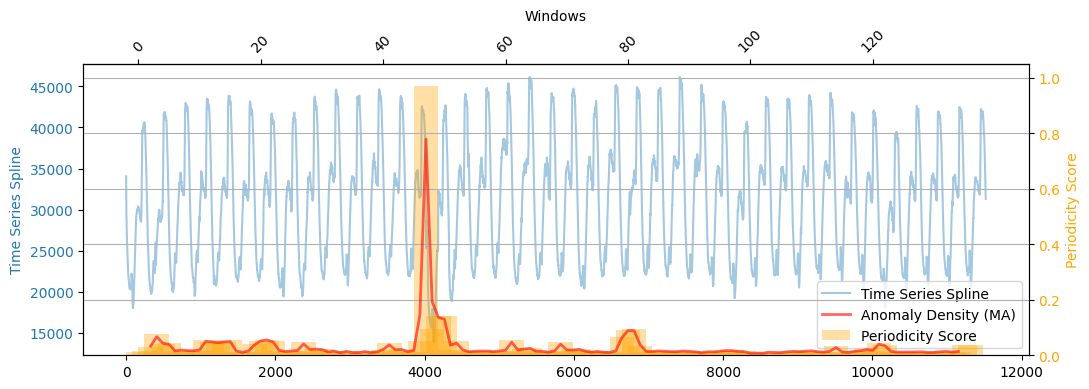

In [10]:
scores = SW1PerS_L(ts, factor = 2, choose_hyper_param=True)

# algorithm comparison

## LOF (local outlier factor)

In [11]:
from pyod.models.lof import LOF

from sw1pers_l.time_series.sliding_windows import make_sliding_windows

In [12]:
def run_lof(ts, window_size=24, n_neighbors=20):
    X = make_sliding_windows(ts, window_size, window_stride)

    clf = LOF(
        n_neighbors=n_neighbors,
        contamination=0.05
    )

    clf.fit(X)

    scores = clf.decision_scores_

    # map back to timeline
    ts_scores = np.zeros(len(ts))
    ts_scores[window_size - 1::window_stride] = scores

    return ts_scores

In [13]:
window_size = len(ts)//35
window_stride = window_size//4

#compute LOF scores
lof_scores = run_lof(ts, window_size=window_size)   # needs sliding_windows function

#filter out zeros
nonzero_lof_scores=[]
for num in lof_scores:
    if num>0.1:
        nonzero_lof_scores.append(num)

In [14]:
from sw1pers_l.sw1pers_scores._density import density

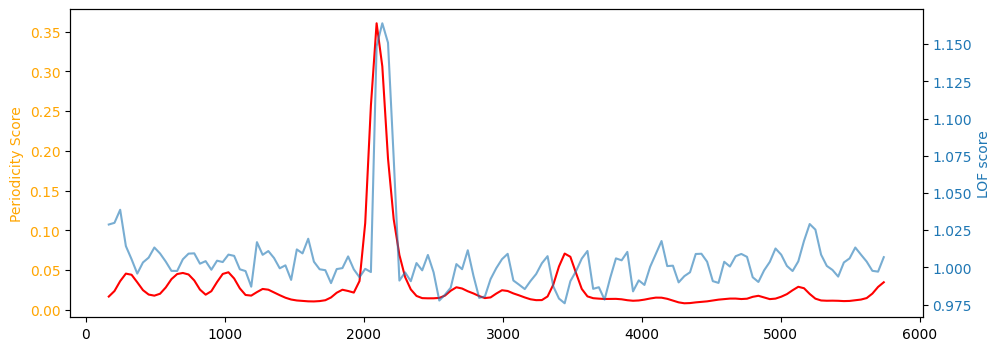

In [15]:
score_lof_arr = []
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

step = len(ts)/len(nonzero_lof_scores)
x_axis = np.arange(window_size, len(ts), window_stride)

ax1.plot(x_axis, density(scores, 10), color = "red")
ax1.set_ylabel("Periodicity Score", color = 'orange')
ax1.tick_params(axis='y', labelcolor = 'orange')

ax2.plot(x_axis, nonzero_lof_scores, label="LOF score", alpha=0.6)
ax2.set_ylabel("LOF score", color = "C0")
ax2.tick_params(axis='y', labelcolor = "C0")

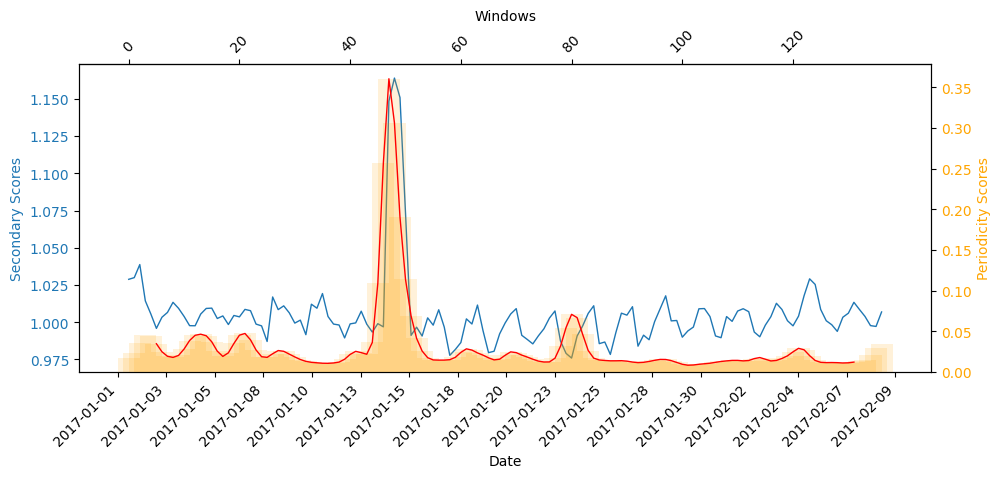

In [16]:
from sw1pers_l.sw1pers_scores.plot import plot_scores_comparison

# standard --> rolling_size_scores = window_size/window_stride

plot_scores_comparison(density(scores, 10), nonzero_lof_scores, window_size, window_stride, dates, rolling_size_scores=10)